# 06 — Visualization Notebook: Thesis Figures and Multilayer Views

This notebook is dedicated to the main figures for the thesis and final presentation. It turns the scenario outputs and country-layer results into clear, publication-quality visuals with consistent styling and exportable assets.

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath('..'))

from src.network.builder import build_matrices
from src.dynamics.compute_vj import compute_Vj
from src.dynamics.compute_phi import compute_phi
from src.dynamics.compute_damping import compute_damping
from src.simulation.simulator import ShockSimulator

os.makedirs('../outputs/figures', exist_ok=True)

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'font.family': 'DejaVu Sans',
})

PALETTE = {
    'baseline': '#d1495b',
    'damped': '#2a9d8f',
    'common': '#457b9d',
    'delta': '#f4a261',
}

print('Visualization setup ready')

Visualization setup ready


In [3]:
Z, F, X, A, B = build_matrices(2018)
V, IRR_node, input_dist = compute_Vj(A, X, Z=Z)
phi_node, phi_country = compute_phi(lpi_path='../data/raw/lpi.xlsx', nodes=A.index, year=2018)
d, D = compute_damping(V, phi_node)
sim = ShockSimulator(A=A, X=X, D=D, f=None, n_iter=20, phi=1.0)

def filter_nodes(nodes, index):
    return [n for n in nodes if n in index]

SHOCK_SCENARIOS = [
    ('RUS_C19', 'single_node', 'Energy: RUS petroleum refining'),
    ('RUS', 'single_country', 'Energy: Full Russia collapse'),
    (filter_nodes(['RUS_C19','UKR_C19','UKR_A01','UKR_B06','RUS_B06'], A.index), 'multi_node', 'Energy: Ukraine war proxy'),
    (filter_nodes(['SAU_B06','RUS_B06','ROW_B06'], A.index), 'multi_node', 'Oil: OPEC-style extraction shock'),
    (filter_nodes(['USA_K','GBR_K','IRL_K'], A.index), 'multi_node', 'Financial: 2008-style US+UK+IRL finance'),
    (filter_nodes(['USA_A01','BRA_A01','ARG_A01','UKR_A01','AUS_A01'], A.index), 'multi_node', 'Food: Major agricultural exporters shock'),
    (filter_nodes(['CHN_C26','KOR_C26','TWN_C26'], A.index), 'multi_node', 'Tech: Semiconductor shock CHN+KOR+TWN'),
    (filter_nodes([n for n in A.index if any(n.endswith(s) for s in ['_H49','_H50','_H51','_H52','_I'])], A.index), 'multi_node', 'COVID: Global transport + hospitality shutdown'),
]

all_results = {}
for shock, mode, label in SHOCK_SCENARIOS:
    all_results[label] = sim.run(shock=shock, mode=mode, label=label)

summary = sim.summary_table(list(all_results.values()))
country_results = pd.read_csv('../outputs/country_layer_results.csv') if os.path.exists('../outputs/country_layer_results.csv') else None

print('Results loaded for plotting')

Active nodes after zero-output removal: 3928
Computing V_j: Upstream Systemic Exposure
Method: Option C — Global Export Concentration (IRR)

[1/3] Building input distribution matrix...
  Input distribution : (3928, 3928)
  Zero-input sectors : 0

[2/3] Computing IRR: global export concentration per sector...
  Computing export flows (cross-border only)...
  This may take a moment for 3928 nodes...
  Nodes with positive exports : 3918
  Non-exporting nodes         : 10
  Total export volume         : 12398232.52

  Global EXPORT concentration IRR by sector code:
  Top 10 most concentrated (irreplaceable export markets):
sector_code
B05         0.222951
C13T15      0.182886
B06         0.154113
B09         0.145945
C302T309    0.140728
C301        0.136797
J58T60      0.119016
C26         0.117303
H53         0.109292
C27         0.106891

  Bottom 10 least concentrated (substitutable export markets):
sector_code
H52       0.030460
C10T12    0.034768
H49       0.036281
F         0.045223

c:\Users\Aditya\anaconda3\envs\wion\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


  LPI countries not mapped to ICIO (78): ['Qatar', 'Panama', 'Oman', 'Rwanda', 'Bahrain', 'Kuwait', 'Serbia', 'Kenya', 'Bosnia and Herzegovina', 'Paraguay', 'Benin', 'Montenegro', 'Mauritius', 'Lebanon', 'Macedonia, FYR', 'Uruguay', 'Maldives', 'Dominican Republic', 'Albania', 'Djibouti', 'Burkina Faso', 'Armenia', 'Honduras', 'Sri Lanka', 'Mali', 'Malawi', 'Uzbekistan', 'El Salvador', 'Uganda', 'Solomon Islands', 'Ghana', 'Comoros', 'Kyrgyz Republic', 'Zambia', 'Bahamas, The', 'Jamaica', 'Nepal', 'Congo, Rep.', 'Moldova', 'Algeria', 'Togo', 'Georgia', 'Sudan', 'Chad', 'Trinidad and Tobago', 'Guatemala', 'Turkmenistan', 'Gambia, The', 'Madagascar', 'Guinea-Bissau', 'Mongolia', 'Bolivia', 'Guyana', 'Fiji', 'Tajikistan', 'Mauritania', 'Equatorial Guinea', 'Syrian Arab Republic', 'Lesotho', 'Yemen, Rep.', 'Venezuela, RB', 'Liberia', 'Somalia', 'Guinea', 'Cuba', 'Iraq', 'Papua New Guinea', 'Bhutan', 'Gabon', 'Central African Republic', 'Zimbabwe', 'Haiti', 'Libya', 'Eritrea', 'Sierra Leone

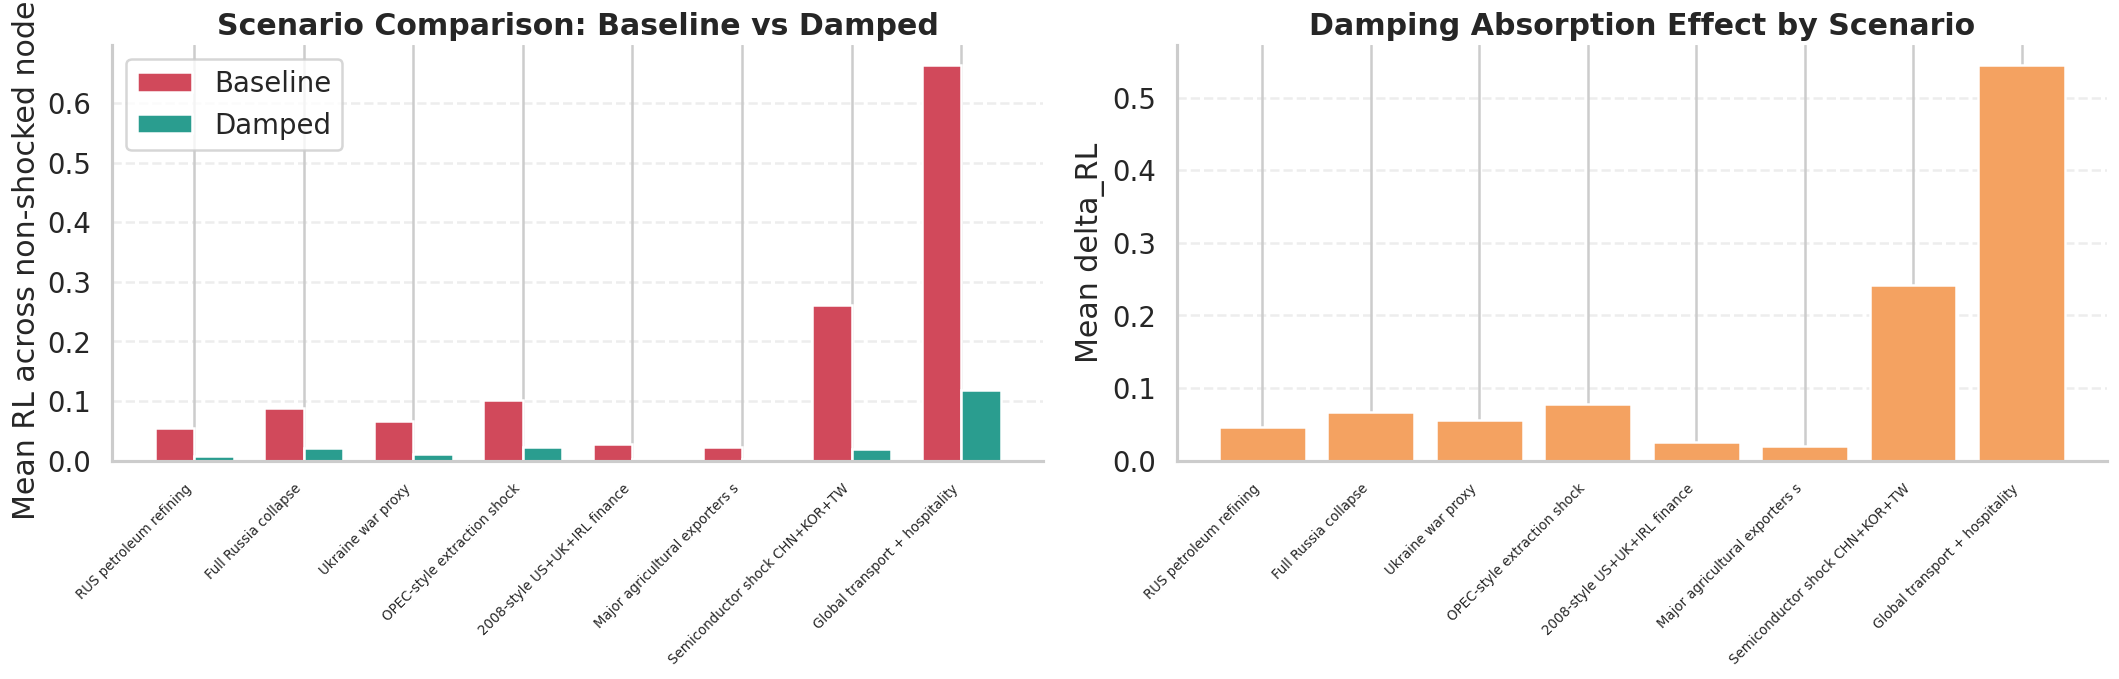

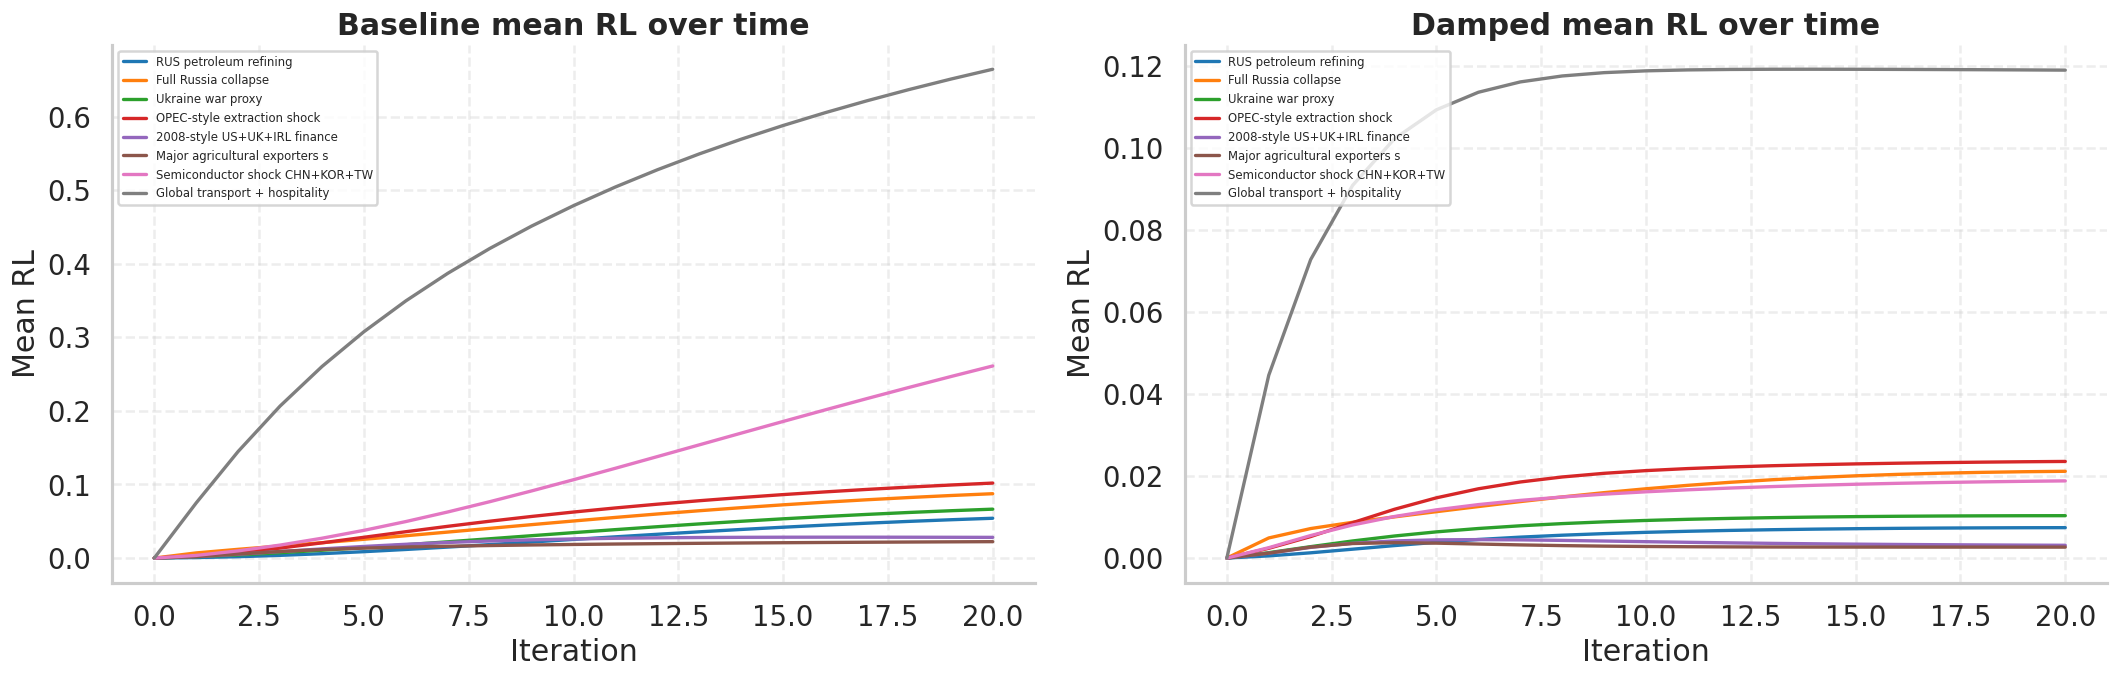

In [4]:
# Headline comparison: final mean RL and absorption by scenario
labels = list(all_results.keys())
short_labels = [l.split(':')[-1].strip()[:30] for l in labels]

mean_base = []
mean_damp = []
mean_delta = []

for label, r in all_results.items():
    shock_nodes = r['shock_nodes']
    base = r['RL_final_base'].drop(index=shock_nodes, errors='ignore')
    damp = r['RL_final_damp'].drop(index=shock_nodes, errors='ignore') if r['RL_final_damp'] is not None else None
    delta = r['delta_RL'].drop(index=shock_nodes, errors='ignore') if r['delta_RL'] is not None else None
    mean_base.append(base.mean())
    mean_damp.append(damp.mean() if damp is not None else np.nan)
    mean_delta.append(delta.mean() if delta is not None else np.nan)

x = np.arange(len(labels))
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].bar(x - 0.18, mean_base, width=0.36, color=PALETTE['baseline'], label='Baseline')
axes[0].bar(x + 0.18, mean_damp, width=0.36, color=PALETTE['damped'], label='Damped')
axes[0].set_xticks(x)
axes[0].set_xticklabels(short_labels, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Mean RL across non-shocked nodes')
axes[0].set_title('Scenario Comparison: Baseline vs Damped')
axes[0].legend()

axes[1].bar(x, mean_delta, color=PALETTE['delta'])
axes[1].set_xticks(x)
axes[1].set_xticklabels(short_labels, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Mean delta_RL')
axes[1].set_title('Damping Absorption Effect by Scenario')
for ax in axes:
    ax.grid(axis='y', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig('../outputs/figures/scenario_comparison_bars.png', bbox_inches='tight')
plt.show()

# Time series overlay
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
colors = sns.color_palette('tab10', n_colors=len(all_results))
for i, (label, r) in enumerate(all_results.items()):
    shock_nodes = r['shock_nodes']
    base_ts = r['RL_base'].drop(columns=shock_nodes, errors='ignore').mean(axis=1)
    damp_ts = r['RL_damp'].drop(columns=shock_nodes, errors='ignore').mean(axis=1) if r['RL_damp'] is not None else None
    axes[0].plot(base_ts.index, base_ts.values, color=colors[i], linewidth=2, label=short_labels[i])
    if damp_ts is not None:
        axes[1].plot(damp_ts.index, damp_ts.values, color=colors[i], linewidth=2, label=short_labels[i])

for ax, title in zip(axes, ['Baseline mean RL over time', 'Damped mean RL over time']):
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Mean RL')
    ax.set_title(title)
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig('../outputs/figures/timeseries_overlay.png', bbox_inches='tight')
plt.show()

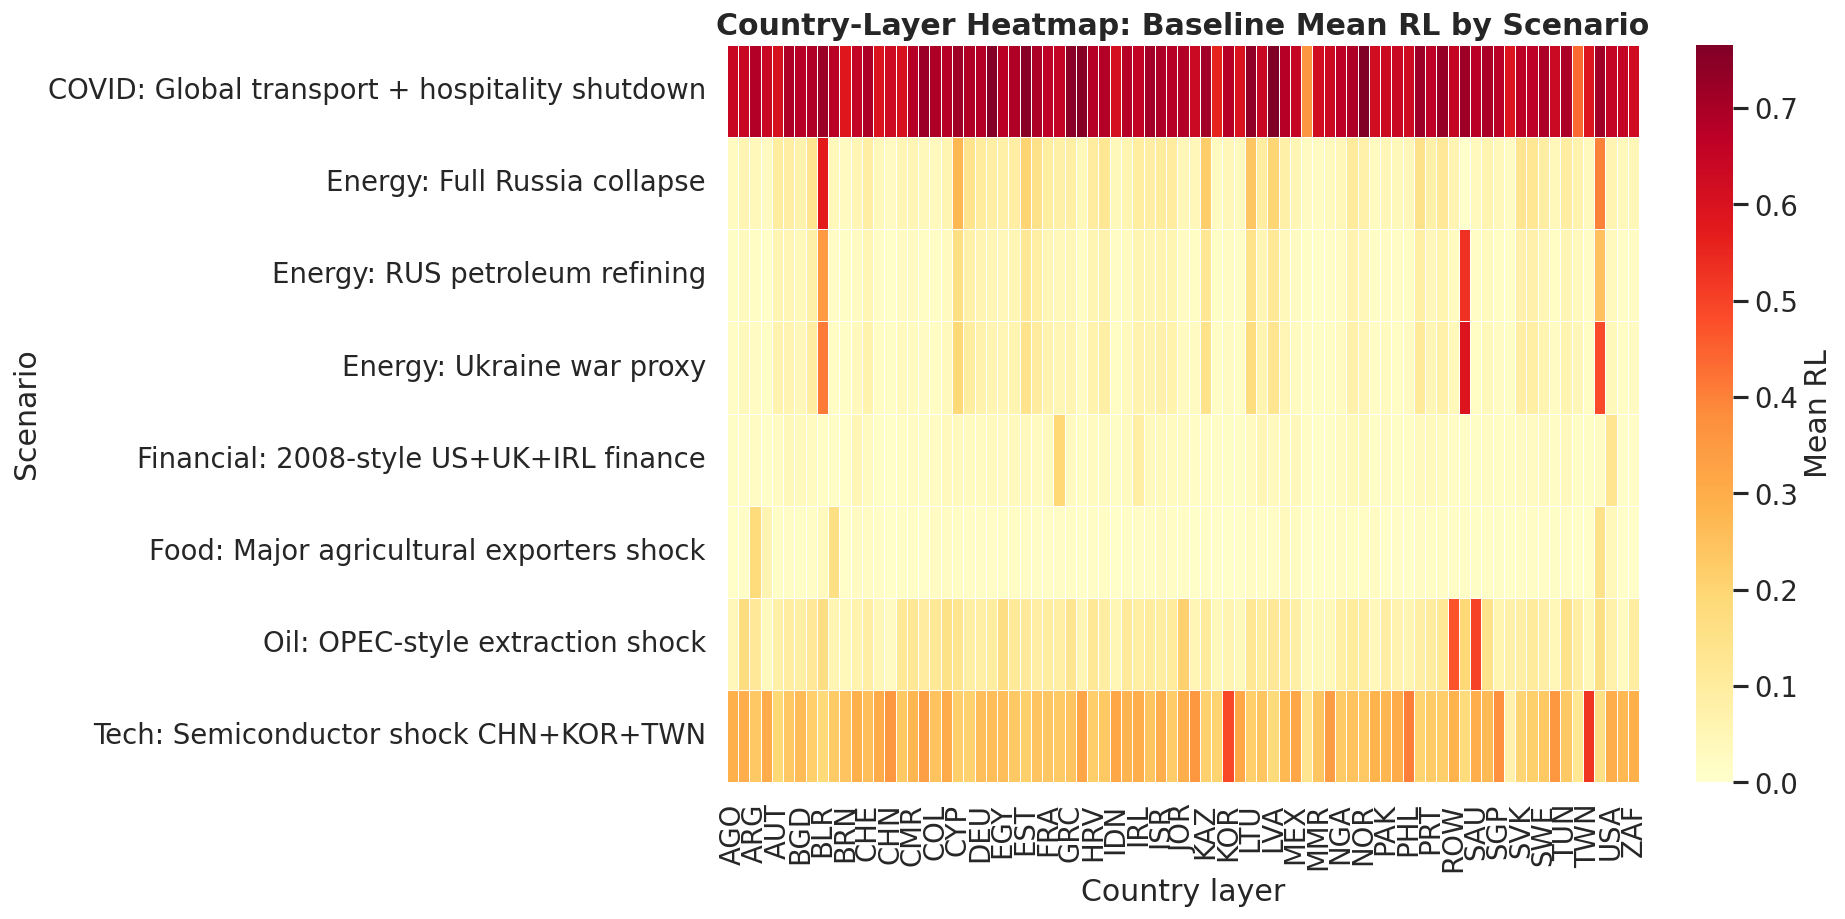

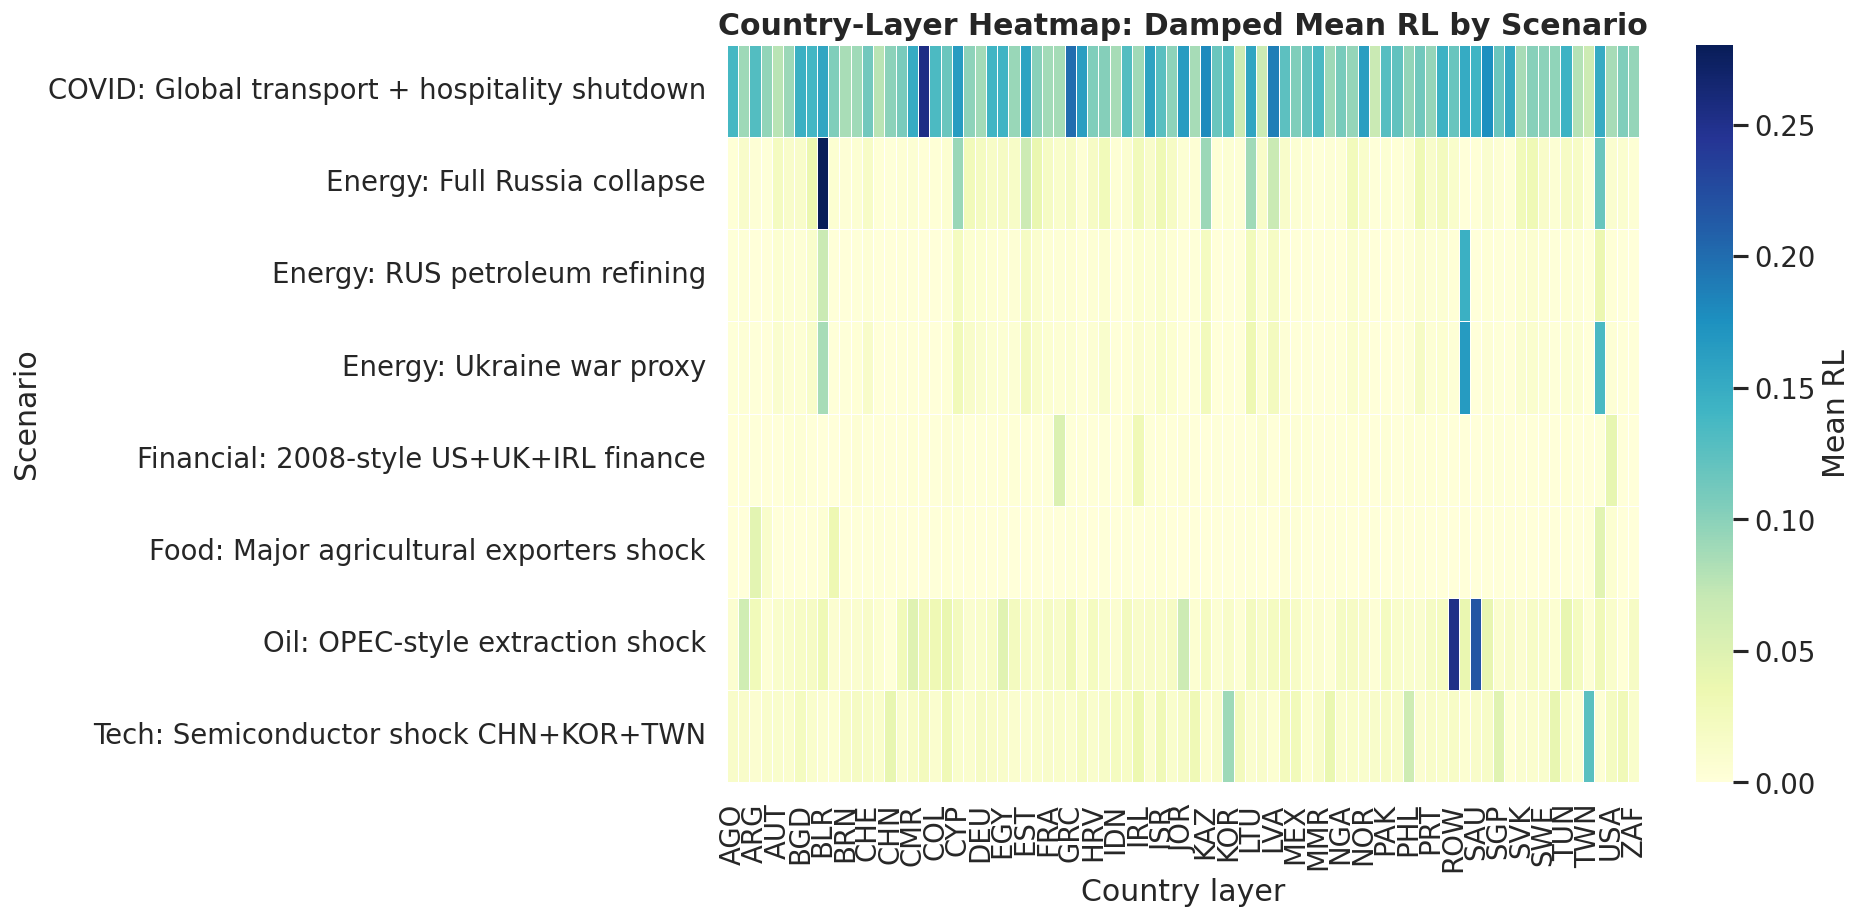

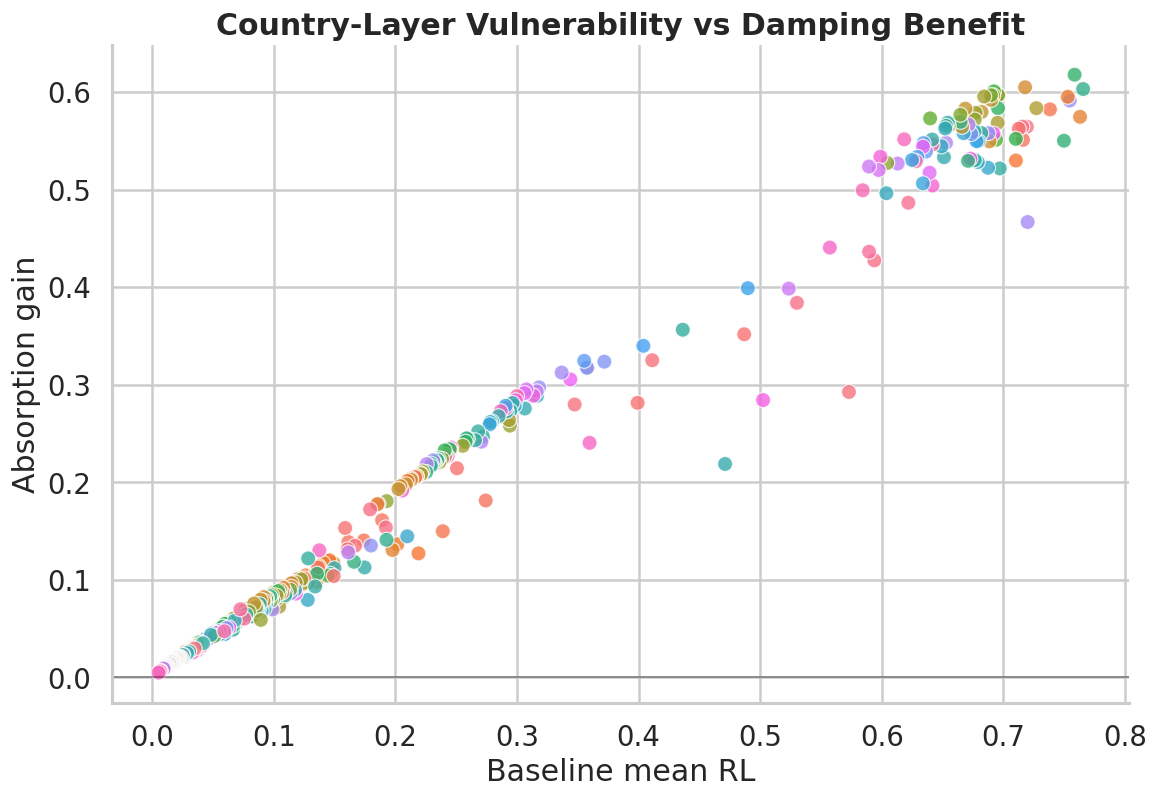

In [5]:
# Multilayer view: country-layer heatmap from aggregated country results
if country_results is None:
    print('country_results not found; run the results notebook first.')
else:
    base_country = country_results[(country_results['metric'] == 'baseline')].copy()
    damp_country = country_results[(country_results['metric'] == 'damped')].copy() if 'damped' in country_results['metric'].unique() else None

    pivot = base_country.pivot_table(index='scenario', columns='country', values='mean_rl', aggfunc='mean').fillna(0)
    fig, ax = plt.subplots(figsize=(16, 8))
    sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, linecolor='white', ax=ax, cbar_kws={'label': 'Mean RL'})
    ax.set_title('Country-Layer Heatmap: Baseline Mean RL by Scenario')
    ax.set_xlabel('Country layer')
    ax.set_ylabel('Scenario')
    plt.tight_layout()
    plt.savefig('../outputs/figures/country_layer_heatmap_baseline.png', bbox_inches='tight')
    plt.show()

    if damp_country is not None:
        pivot_d = damp_country.pivot_table(index='scenario', columns='country', values='mean_rl', aggfunc='mean').fillna(0)
        fig, ax = plt.subplots(figsize=(16, 8))
        sns.heatmap(pivot_d, cmap='YlGnBu', linewidths=0.3, linecolor='white', ax=ax, cbar_kws={'label': 'Mean RL'})
        ax.set_title('Country-Layer Heatmap: Damped Mean RL by Scenario')
        ax.set_xlabel('Country layer')
        ax.set_ylabel('Scenario')
        plt.tight_layout()
        plt.savefig('../outputs/figures/country_layer_heatmap_damped.png', bbox_inches='tight')
        plt.show()

    # Absorption vs vulnerability scatter
    if damp_country is not None:
        merged = base_country.merge(damp_country[['scenario', 'country', 'mean_rl']], on=['scenario', 'country'], suffixes=('_base', '_damp'))
        merged['absorption_gain'] = merged['mean_rl_base'] - merged['mean_rl_damp']
        fig, ax = plt.subplots(figsize=(10, 7))
        sns.scatterplot(data=merged, x='mean_rl_base', y='absorption_gain', hue='country', alpha=0.8, ax=ax, legend=False)
        ax.axhline(0, color='black', linewidth=1, alpha=0.4)
        ax.set_xlabel('Baseline mean RL')
        ax.set_ylabel('Absorption gain')
        ax.set_title('Country-Layer Vulnerability vs Damping Benefit')
        plt.tight_layout()
        plt.savefig('../outputs/figures/vulnerability_absorption_scatter.png', bbox_inches='tight')
        plt.show()

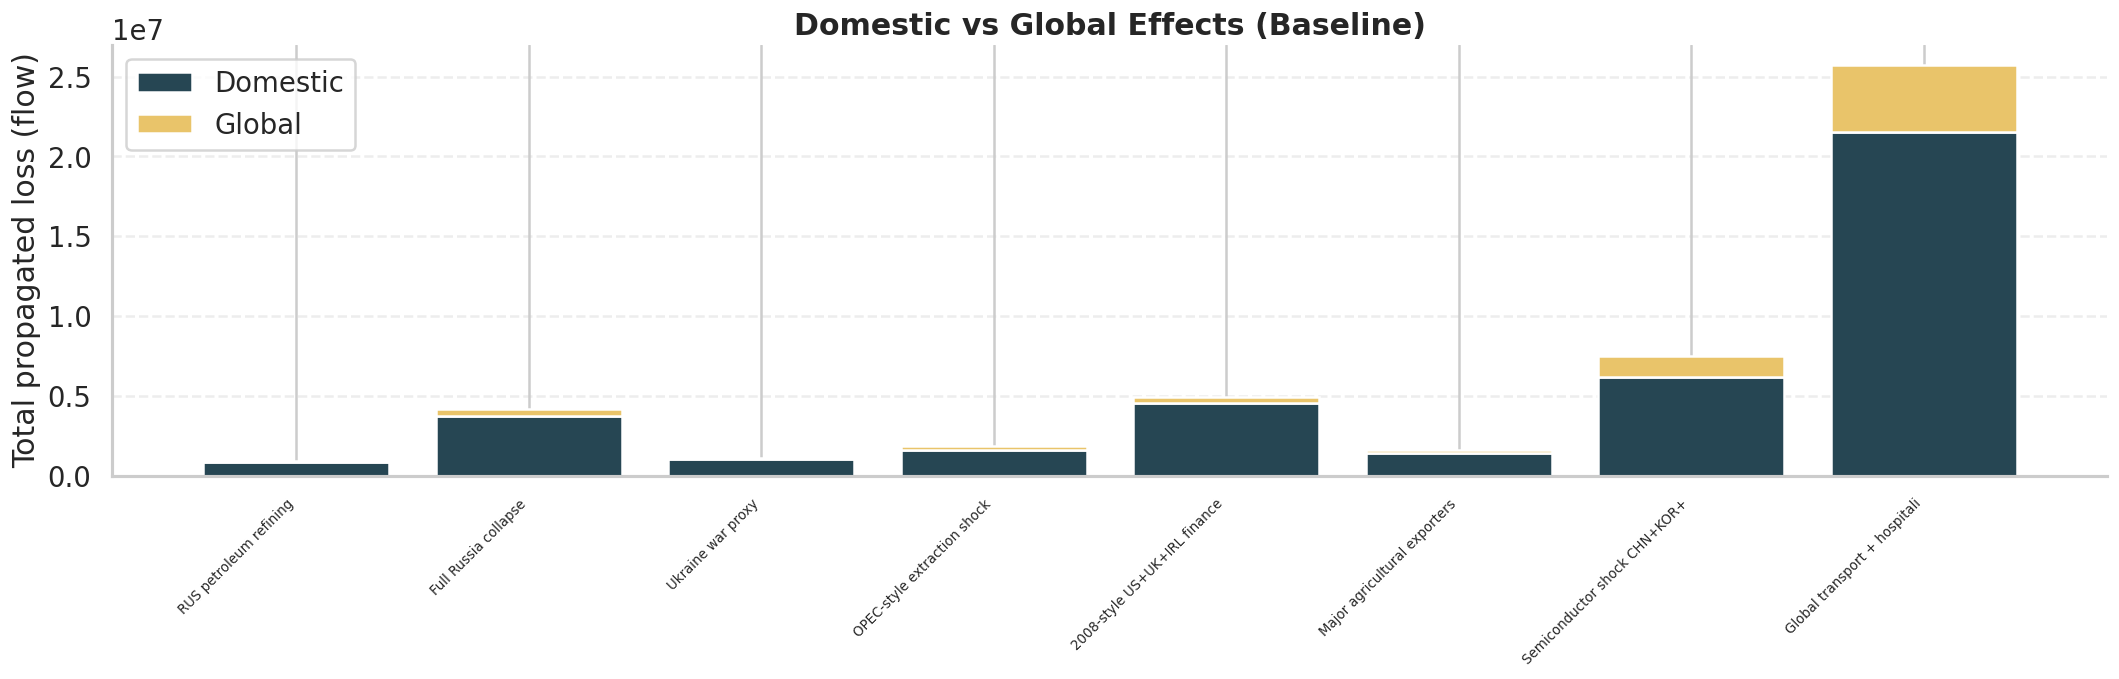

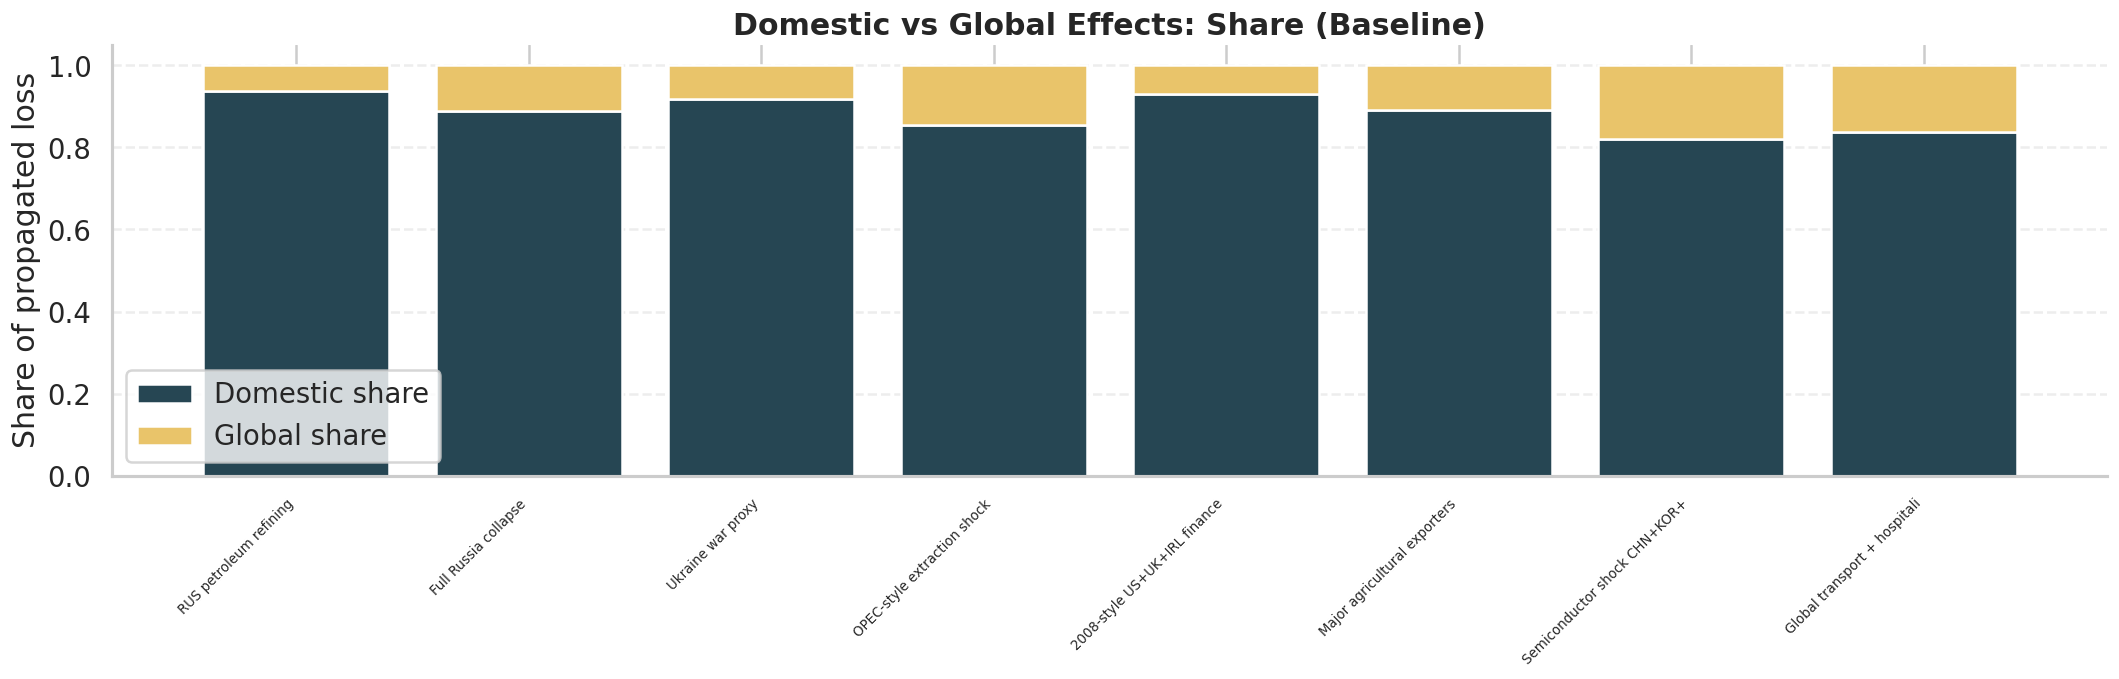

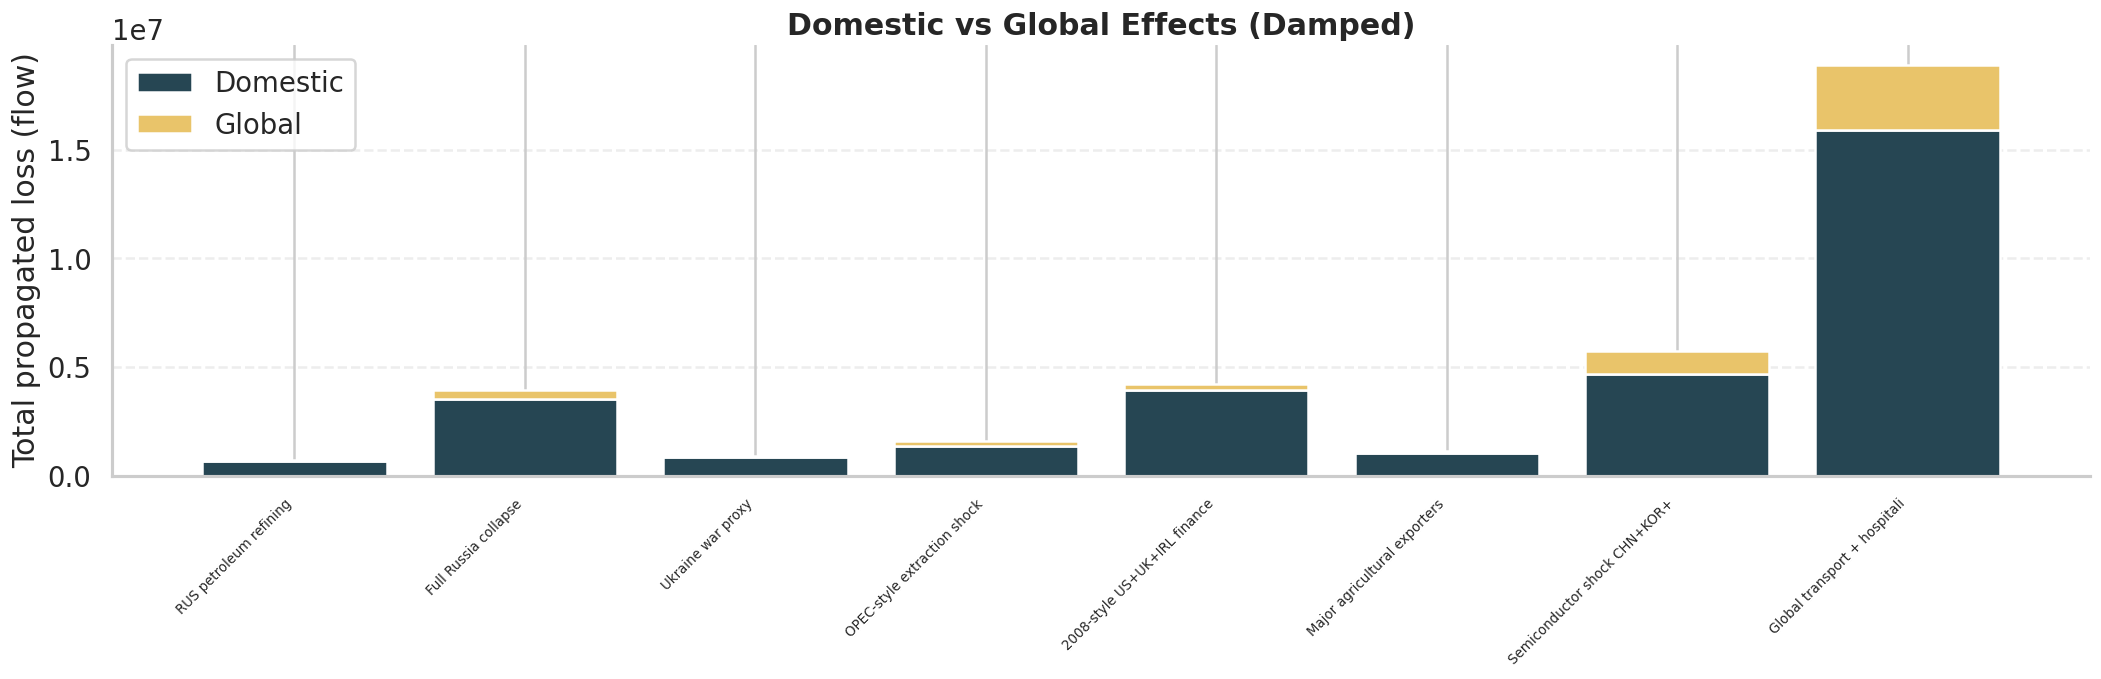

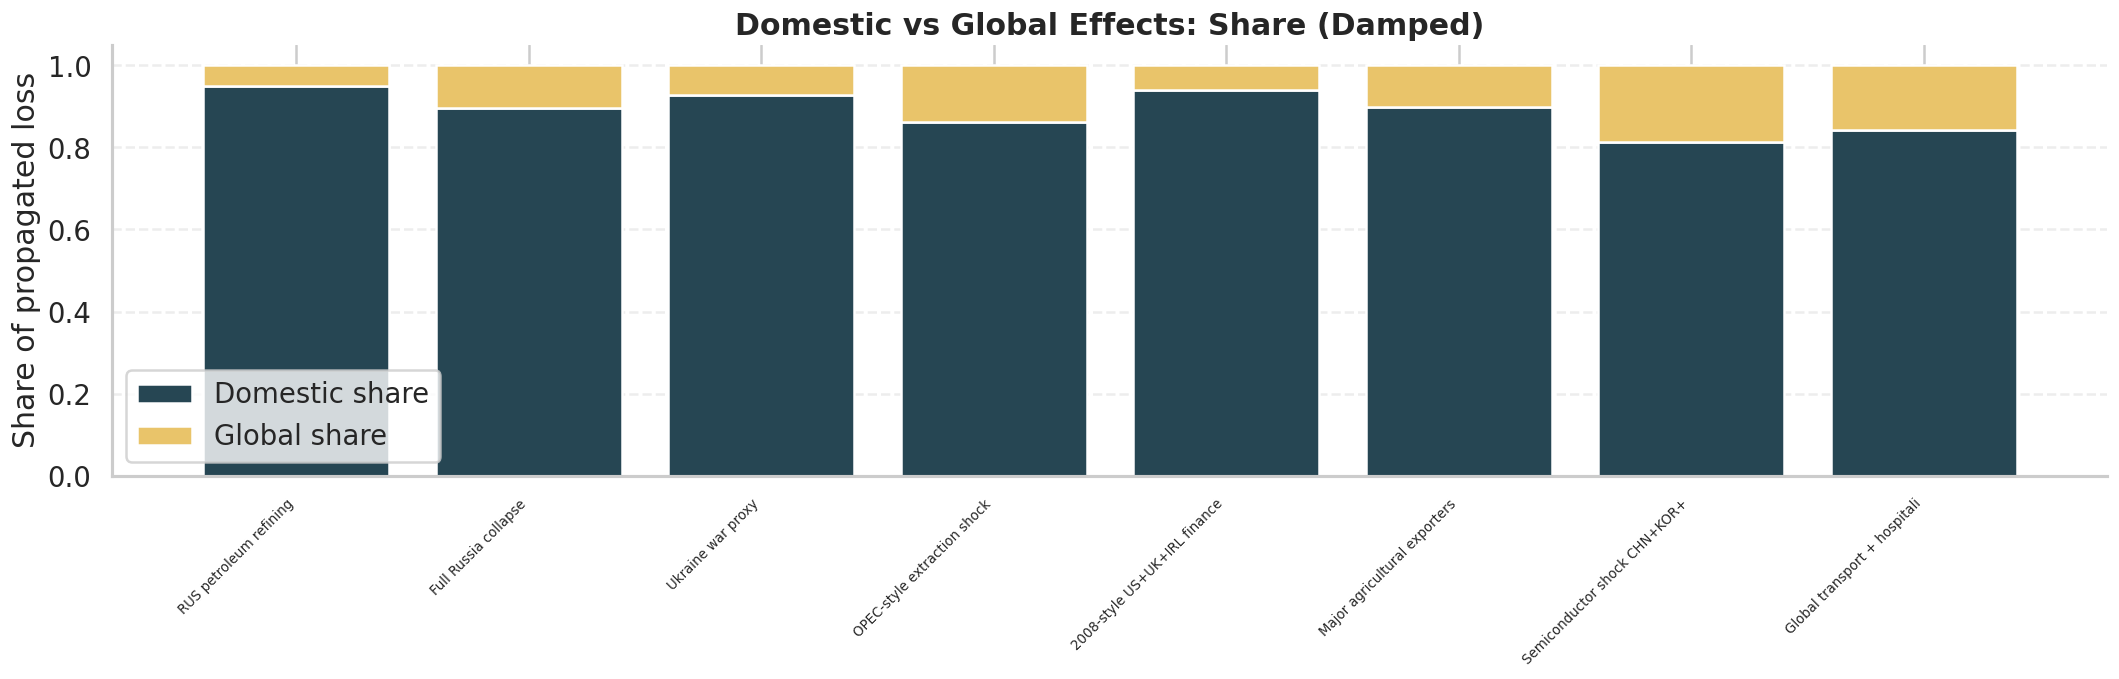

In [6]:
# Domestic vs global effects by scenario
spillover_path = '../outputs/country_layer_spillovers.csv'
if not os.path.exists(spillover_path):
    print('country_layer_spillovers.csv not found; run the results notebook first.')
else:
    spill = pd.read_csv(spillover_path)
    scenario_order = list(all_results.keys()) if 'all_results' in globals() else sorted(spill['scenario'].unique())

    def build_domestic_global(metric):
        df = spill[spill['metric'] == metric].copy()
        if df.empty:
            return None
        df['is_domestic'] = df['destination_country'] == df['source_country']
        agg = df.groupby(['scenario', 'is_domestic'])['flow'].sum().reset_index()
        pivot = agg.pivot(index='scenario', columns='is_domestic', values='flow').fillna(0.0)
        pivot = pivot.rename(columns={True: 'domestic', False: 'global'})
        pivot = pivot.reindex(scenario_order)
        pivot['total'] = pivot['domestic'] + pivot['global']
        pivot['domestic_share'] = pivot['domestic'] / pivot['total'].replace(0, np.nan)
        pivot['global_share'] = pivot['global'] / pivot['total'].replace(0, np.nan)
        return pivot

    def plot_abs(pivot, title, save_name):
        if pivot is None:
            return
        short_labels = [s.split(':')[-1].strip()[:28] for s in pivot.index]
        x = np.arange(len(pivot))
        fig, ax = plt.subplots(figsize=(18, 6))
        ax.bar(x, pivot['domestic'], color='#264653', label='Domestic')
        ax.bar(x, pivot['global'], bottom=pivot['domestic'], color='#e9c46a', label='Global')
        ax.set_xticks(x)
        ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('Total propagated loss (flow)')
        ax.set_title(title)
        ax.legend()
        ax.grid(axis='y', linestyle='--', alpha=0.35)
        plt.tight_layout()
        plt.savefig(save_name, bbox_inches='tight')
        plt.show()

    def plot_share(pivot, title, save_name):
        if pivot is None:
            return
        short_labels = [s.split(':')[-1].strip()[:28] for s in pivot.index]
        x = np.arange(len(pivot))
        fig, ax = plt.subplots(figsize=(18, 6))
        ax.bar(x, pivot['domestic_share'], color='#264653', label='Domestic share')
        ax.bar(x, pivot['global_share'], bottom=pivot['domestic_share'], color='#e9c46a', label='Global share')
        ax.set_xticks(x)
        ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('Share of propagated loss')
        ax.set_title(title)
        ax.legend()
        ax.grid(axis='y', linestyle='--', alpha=0.35)
        plt.tight_layout()
        plt.savefig(save_name, bbox_inches='tight')
        plt.show()

    for metric, label in [('baseline', 'Baseline'), ('damped', 'Damped')]:
        pivot = build_domestic_global(metric)
        if pivot is None:
            print(f'No {metric} rows found in spillover data.')
            continue
        plot_abs(pivot, f'Domestic vs Global Effects ({label})', f'../outputs/figures/domestic_global_{metric}_abs.png')
        plot_share(pivot, f'Domestic vs Global Effects: Share ({label})', f'../outputs/figures/domestic_global_{metric}_share.png')

In [ ]:
# Major-country domestic vs global effects for small-node shocks
spillover_path = '../outputs/country_layer_spillovers.csv'
major_country_figs = []

if not os.path.exists(spillover_path):
    print('country_layer_spillovers.csv not found; run the results notebook first.')
else:
    spill = pd.read_csv(spillover_path)

    if 'all_results' in globals():
        small_scenarios = [
            label for label, r in all_results.items()
            if len(r.get('shock_nodes', [])) <= 3
        ]
    else:
        small_scenarios = sorted(spill['scenario'].unique())

    if not small_scenarios:
        small_scenarios = sorted(spill['scenario'].unique())

    major_countries = ['USA', 'CHN', 'DEU', 'JPN', 'GBR', 'FRA', 'IND', 'BRA', 'RUS', 'CAN', 'KOR', 'AUS']
    available_countries = sorted(set(spill['destination_country'].unique()))
    major_countries = [c for c in major_countries if c in available_countries]
    if not major_countries:
        major_countries = available_countries[:10]

    def slugify(text):
        return ''.join([c.lower() if c.isalnum() else '_' for c in text]).strip('_')

    def country_domestic_global(df, scenario):
        subset = df[df['scenario'] == scenario].copy()
        if subset.empty:
            return None
        subset = subset[subset['destination_country'].isin(major_countries)]
        if subset.empty:
            return None
        total = subset.groupby('destination_country')['flow'].sum()
        domestic = subset[subset['destination_country'] == subset['source_country']].groupby('destination_country')['flow'].sum()
        out = pd.DataFrame({'total': total, 'domestic': domestic}).fillna(0.0)
        out['global'] = out['total'] - out['domestic']
        out['domestic_share'] = out['domestic'] / out['total'].replace(0, np.nan)
        out['global_share'] = out['global'] / out['total'].replace(0, np.nan)
        return out

    for metric in ['baseline', 'damped']:
        dfm = spill[spill['metric'] == metric]
        if dfm.empty:
            continue
        for scenario in small_scenarios:
            pivot = country_domestic_global(dfm, scenario)
            if pivot is None:
                continue
            short_scenario = scenario.split(':')[-1].strip()
            x = np.arange(len(pivot))
            fig, axes = plt.subplots(1, 2, figsize=(16, 5))

            axes[0].bar(x, pivot['domestic'], color='#264653', label='Domestic')
            axes[0].bar(x, pivot['global'], bottom=pivot['domestic'], color='#e9c46a', label='Global')
            axes[0].set_xticks(x)
            axes[0].set_xticklabels(pivot.index, rotation=45, ha='right', fontsize=8)
            axes[0].set_ylabel('Total propagated loss (flow)')
            axes[0].set_title(f'{short_scenario} ({metric.title()}): Domestic vs Global')
            axes[0].legend()
            axes[0].grid(axis='y', linestyle='--', alpha=0.35)

            axes[1].bar(x, pivot['domestic_share'], color='#264653', label='Domestic share')
            axes[1].bar(x, pivot['global_share'], bottom=pivot['domestic_share'], color='#e9c46a', label='Global share')
            axes[1].set_xticks(x)
            axes[1].set_xticklabels(pivot.index, rotation=45, ha='right', fontsize=8)
            axes[1].set_ylabel('Share of propagated loss')
            axes[1].set_title(f'{short_scenario} ({metric.title()}): Share')
            axes[1].legend()
            axes[1].grid(axis='y', linestyle='--', alpha=0.35)

            plt.tight_layout()
            fname = f'major_country_domestic_global_{metric}_{slugify(scenario)}.png'
            path = f'../outputs/figures/{fname}'
            plt.savefig(path, bbox_inches='tight')
            plt.show()

            major_country_figs.append({'figure': fname, 'path': path})

In [ ]:
os.makedirs('../outputs/figures', exist_ok=True)

# Export summary figure metadata for later PPT assembly
base_manifest = [
    {'figure': 'scenario_comparison_bars.png', 'path': '../outputs/figures/scenario_comparison_bars.png'},
    {'figure': 'timeseries_overlay.png', 'path': '../outputs/figures/timeseries_overlay.png'},
    {'figure': 'country_layer_heatmap_baseline.png', 'path': '../outputs/figures/country_layer_heatmap_baseline.png'},
    {'figure': 'country_layer_heatmap_damped.png', 'path': '../outputs/figures/country_layer_heatmap_damped.png'},
    {'figure': 'vulnerability_absorption_scatter.png', 'path': '../outputs/figures/vulnerability_absorption_scatter.png'},
    {'figure': 'domestic_global_baseline_abs.png', 'path': '../outputs/figures/domestic_global_baseline_abs.png'},
    {'figure': 'domestic_global_baseline_share.png', 'path': '../outputs/figures/domestic_global_baseline_share.png'},
    {'figure': 'domestic_global_damped_abs.png', 'path': '../outputs/figures/domestic_global_damped_abs.png'},
    {'figure': 'domestic_global_damped_share.png', 'path': '../outputs/figures/domestic_global_damped_share.png'},
]

extra_manifest = major_country_figs if 'major_country_figs' in globals() else []

export_manifest = pd.DataFrame(base_manifest + extra_manifest)
export_manifest.to_csv('../outputs/figures/figure_manifest.csv', index=False)
display(export_manifest)

print('Figure exports complete')

,figure,path
0,scenario_comparison_bars.png,../outputs/figures/scenario_comparison_bars.png
1,timeseries_overlay.png,../outputs/figures/timeseries_overlay.png
2,country_layer_heatmap_baseline.png,../outputs/figures/country_layer_heatmap_basel...
3,country_layer_heatmap_damped.png,../outputs/figures/country_layer_heatmap_dampe...
4,vulnerability_absorption_scatter.png,../outputs/figures/vulnerability_absorption_sc...


Figure exports complete
